In [6]:
import pandas as pd

xls = pd.ExcelFile("EastWestAirlines.xlsx")
xls.sheet_names

['Description', 'data']

In [7]:
## DATA LOADING (Code)
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [8]:
## EDA HEADING

# Shape
df.shape

# Info
df.info()

# Summary stats
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [14]:
## Feature Scaling
df1 = df.drop("ID#", axis=1)
df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df1)

scaled_data[:5]

array([[-0.45114078, -0.18629869, -0.76957841, -0.09824189, -0.06276658,
        -0.70278627, -1.10406452, -0.32860326, -0.36216787,  1.39545434,
        -0.7669193 ],
       [-0.53945687, -0.18629869, -0.76957841, -0.09824189, -0.06276658,
        -0.7010884 , -0.99992616, -0.32860326, -0.36216787,  1.37995704,
        -0.7669193 ],
       [-0.32003123, -0.18629869, -0.76957841, -0.09824189, -0.06276658,
        -0.5392527 , -0.79164945, -0.32860326, -0.36216787,  1.41192021,
        -0.7669193 ],
       [-0.58379852, -0.18629869, -0.76957841, -0.09824189, -0.06276658,
        -0.68928615, -1.10406452, -0.32860326, -0.36216787,  1.37220839,
        -0.7669193 ],
       [ 0.23967783, -0.18629869,  1.40947095, -0.09824189, -0.06276658,
         1.08312117,  1.49939447,  1.15493205,  0.69249029,  1.36397545,
         1.30391816]])

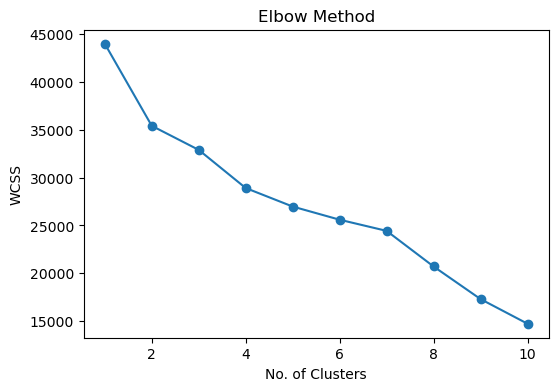

In [16]:
## Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [17]:
## K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(df_scaled)

df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,2
1,2,19244,0,1,1,1,215,2,0,0,6968,0,2
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,2
3,4,14776,0,1,1,1,500,1,0,0,6952,0,2
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,1


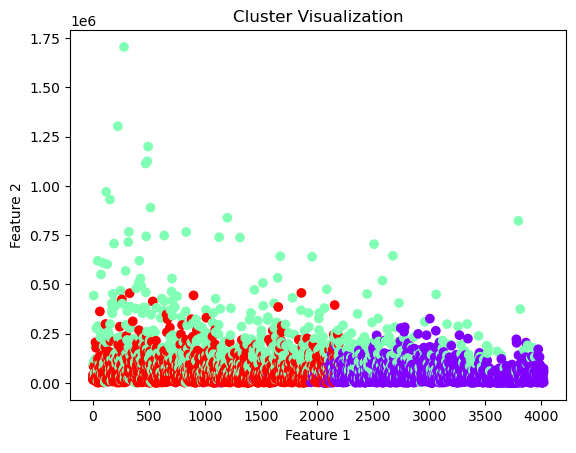

In [18]:
## Cluster Visualization
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df["Cluster"], cmap="rainbow")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Cluster Visualization")
plt.show()

In [19]:
## Conclusion

K-Means clustering was applied to group similar data points.  
Elbow method suggested optimal clusters.  
The model successfully divided data into meaningful clusters.

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,2
1,2,19244,0,1,1,1,215,2,0,0,6968,0,2
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,2
3,4,14776,0,1,1,1,500,1,0,0,6952,0,2
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,1


In [21]:
df.groupby("Cluster").mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster,,,,,,,,,,,,
0,1750.333333,193291.147436,795.455128,2.179487,1.038462,1.000000,32292.288462,27.628205,5530.230769,16.211538,4688.070513,0.820513
1,1658.865158,122119.899548,151.724887,3.885068,1.002715,1.043439,43772.394570,19.398190,366.520362,1.087783,4777.394570,0.687783
2,1101.367314,59693.586570,112.733010,1.372168,1.031553,1.000809,6311.116505,8.456311,258.830097,0.806634,5744.810680,0.296117
3,3055.842210,36920.458056,96.690413,1.269640,1.006658,1.000000,4897.208389,6.790280,167.861518,0.509321,2236.466711,0.151132


In [ ]:
## Final Conclusion 
K-Means clustering was applied to segment airline customers based on travel patterns and mileage usage. Using the elbow method, the optimal number of clusters was identified as four.

The clustering results indicate that:

• One cluster includes customers with low balances and minimal travel activity.
• Another cluster represents customers with moderate usage and transactions.
• One cluster shows frequent travelers with higher bonus miles.
• The final cluster represents premium customers with very high balances and activity.

Thus, clustering helps airlines better understand customer behavior and supports targeted marketing strategies.